In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
data = pd.read_csv("cold_chain_temperature.csv")
print("Dataset Loaded Successfully")
print(data.head())

Dataset Loaded Successfully
   Temperature  Humidity  Storage_Hours  Door_Openings  Cooling_Efficiency  \
0          6.1      73.5           35.7              4                57.8   
1         11.5      63.0           34.6              5                52.8   
2          2.0      74.8           30.4              9                76.2   
3          8.7      49.2           15.4              2                69.1   
4         11.5      65.4           22.7              1                97.4   

   Battery_Level  Temperature_Change    Status  
0           53.6                0.23  Critical  
1           84.7                3.75  Critical  
2           68.8                1.16   Warning  
3           99.1                1.87   Warning  
4           98.1                3.23  Critical  


In [3]:
print("Dataset Shape:", data.shape)
print("\nColumn Names:")
print(data.columns)
print("\n Rows:")
print(data.head())

Dataset Shape: (500, 8)

Column Names:
Index(['Temperature', 'Humidity', 'Storage_Hours', 'Door_Openings',
       'Cooling_Efficiency', 'Battery_Level', 'Temperature_Change', 'Status'],
      dtype='str')

 Rows:
   Temperature  Humidity  Storage_Hours  Door_Openings  Cooling_Efficiency  \
0          6.1      73.5           35.7              4                57.8   
1         11.5      63.0           34.6              5                52.8   
2          2.0      74.8           30.4              9                76.2   
3          8.7      49.2           15.4              2                69.1   
4         11.5      65.4           22.7              1                97.4   

   Battery_Level  Temperature_Change    Status  
0           53.6                0.23  Critical  
1           84.7                3.75  Critical  
2           68.8                1.16   Warning  
3           99.1                1.87   Warning  
4           98.1                3.23  Critical  


In [4]:
X = data[
    [
        "Temperature",
        "Humidity",
        "Door_Openings"
    ]
]
y = data["Status"]
print("Features:")
print(X.head())
print("\nTarget:")
print(y.head())

Features:
   Temperature  Humidity  Door_Openings
0          6.1      73.5              4
1         11.5      63.0              5
2          2.0      74.8              9
3          8.7      49.2              2
4         11.5      65.4              1

Target:
0    Critical
1    Critical
2     Warning
3     Warning
4    Critical
Name: Status, dtype: str


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (400, 3)
Testing Data: (100, 3)


In [9]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [10]:
y_pred = model.predict(X_test)
print("Prediction Completed Successfully")
print(y_pred)

Prediction Completed Successfully
['Critical' 'Critical' 'Critical' 'Critical' 'Critical' 'Critical'
 'Warning' 'Critical' 'Critical' 'Critical' 'Warning' 'Critical'
 'Critical' 'Critical' 'Critical' 'Critical' 'Critical' 'Warning'
 'Critical' 'Critical' 'Warning' 'Critical' 'Critical' 'Critical'
 'Critical' 'Warning' 'Critical' 'Critical' 'Warning' 'Critical'
 'Critical' 'Critical' 'Warning' 'Warning' 'Critical' 'Warning' 'Critical'
 'Warning' 'Critical' 'Critical' 'Warning' 'Critical' 'Critical'
 'Critical' 'Critical' 'Critical' 'Critical' 'Critical' 'Critical'
 'Critical' 'Critical' 'Warning' 'Critical' 'Safe' 'Critical' 'Critical'
 'Critical' 'Warning' 'Warning' 'Critical' 'Warning' 'Warning' 'Critical'
 'Critical' 'Critical' 'Critical' 'Warning' 'Critical' 'Critical'
 'Critical' 'Critical' 'Warning' 'Warning' 'Warning' 'Safe' 'Warning'
 'Warning' 'Critical' 'Critical' 'Warning' 'Critical' 'Warning' 'Critical'
 'Critical' 'Critical' 'Critical' 'Warning' 'Critical' 'Critical'
 'Crit

In [11]:
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:")
print(accuracy)
print("\nAccuracy Percentage:")
print(round(accuracy * 100, 2), "%")


Accuracy:
0.62

Accuracy Percentage:
62.0 %


In [12]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

    Critical       0.72      0.78      0.75        65
        Safe       0.00      0.00      0.00         3
     Warning       0.41      0.34      0.37        32

    accuracy                           0.62       100
   macro avg       0.38      0.38      0.37       100
weighted avg       0.60      0.62      0.61       100



Confusion Matrix:
[[51  0 14]
 [ 1  0  2]
 [19  2 11]]


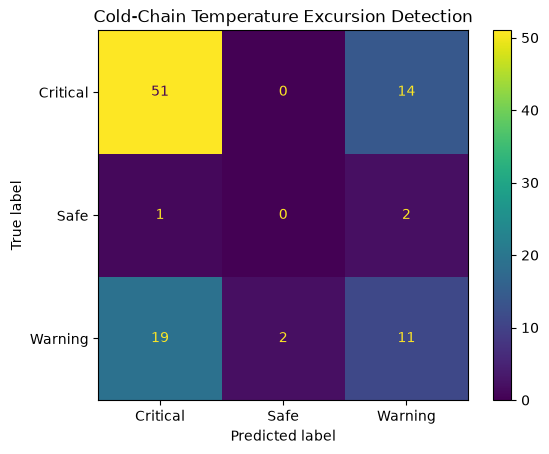

In [13]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)
disp.plot()
plt.title("Cold-Chain Temperature Excursion Detection")
plt.show()

In [14]:
new_data = pd.DataFrame({
    "Temperature": [11],
    "Humidity": [75],
    "Door_Openings": [8]
})
prediction = model.predict(new_data)
print("New Cold-Chain Condition:")
print(new_data)
print("\nPredicted Status:", prediction[0])

New Cold-Chain Condition:
   Temperature  Humidity  Door_Openings
0           11        75              8

Predicted Status: Critical
